In [1]:
import h5py
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt



In [2]:
# Notebook lives in Tellurics/tests/ -> repo root is one level up.
DATA_DIR = Path.cwd().parent / "data"

TEMPLATES_H5 = DATA_DIR / "telluric_templates.h5"
CHUNK_H5    = DATA_DIR / "telluric_timeseries" / "chunks" / "chunk_000001.h5"
CHUNK_H50    = DATA_DIR / "telluric_timeseries" / "chunks" / "chunk_000000.h5"


print("templates exists:", TEMPLATES_H5.exists(), "->", TEMPLATES_H5)
print("chunk exists:    ", CHUNK_H5.exists(), "->", CHUNK_H5)


def inspect_h5(path: Path, max_ds_rows: int = 5):
    """Recursively print the groups/datasets, their shapes/dtypes and attributes."""
    with h5py.File(path, "r") as hf:
        def _visit(name, obj):
            indent = "  " * (name.count("/"))
            if isinstance(obj, h5py.Dataset):
                print(f"{indent}[dataset] {name:.<30} shape={obj.shape} dtype={obj.dtype}")
                if obj.attrs:
                    print(f"{indent}  attrs:")
                    for k, v in obj.attrs.items():
                        print(f"{indent}    {k} = {v}")
            elif isinstance(obj, h5py.Group):
                print(f"{indent}[group] {name}")
                if obj.attrs:
                    print(f"{indent}  attrs:")
                    for k, v in obj.attrs.items():
                        print(f"{indent}    {k} = {v}")
        print(f"\n===== {path} =====")
        print("Top-level file attributes:")
        for k, v in hf.attrs.items():
            print(f"  {k} = {v}")
        hf.visititems(_visit)


inspect_h5(TEMPLATES_H5)

templates exists: True -> /home/mvasist/Documents/Tellurics/data/telluric_templates.h5
chunk exists:     True -> /home/mvasist/Documents/Tellurics/data/telluric_timeseries/chunks/chunk_000001.h5

===== /home/mvasist/Documents/Tellurics/data/telluric_templates.h5 =====
Top-level file attributes:
  conditions_h5 = /scratch/andy-ext/TFM_DATA/telfit/conditions/telfit_condition_series.h5
  highfreq_cm1 = 12501.550175048982
  lowfreq_cm1 = 10525.207872855488
  n_frames_per_series = 73
  padding_nm = 0.1
  spectral_config = /scratch/andy-ext/TFM/configs/telfit_spectral_production.toml
  target_resolution = 100000.0
  wavegrid_file = /scratch/andy-ext/TFM_DATA/phoenix/resampled/phoenix_A0V_T9600_logg4p0_fehp0p0_R100000_s3_800-950nm.fits
  wavelength_max_nm = 950.0
  wavelength_medium = vacuum
  wavelength_min_nm = 800.000801098918
[dataset] failed_indices................ shape=(0,) dtype=int64
[dataset] labels........................ shape=(328500, 20) dtype=float32
  attrs:
    columns = ['fl

In [3]:
# Closer look at telluric_templates.h5 contents.
# NOTE: the transmission dataset is ~63 GB, so only read metadata + a small preview slice.
with h5py.File(TEMPLATES_H5, "r") as hf:
    n_models, n_wave = hf["transmission"].shape
    n_models_l, n_labels = hf["labels"].shape
    wl = hf["wavelength"][:]
    cols = list(hf["labels"].attrs["columns"])

    trans_sample = hf["transmission"][:50]     # first 5 rows only
    labels_sample = hf["labels"][:50]
    failed = hf["failed_indices"][:]

print("wavelength   :", wl.shape, wl.dtype, f"-> {wl.min():.3f} .. {wl.max():.3f} nm (median step ~{np.median(np.diff(wl)):.4f} nm)")
print("transmission : full shape", (n_models, n_wave), "float32 | preview", trans_sample.shape, f"range [{trans_sample.min():.4f}, {trans_sample.max():.4f}]")
print("labels       : full shape", (n_models_l, n_labels), "float32")
print("  columns    :", cols)
print("failed_indices:", failed.shape, failed)

print("\nExample label row (first model):")
for c, v in zip(cols, labels_sample[0]):
    print(f"  {c:.<25} {v:.6f}")

wavelength   : (51556,) float64 -> 800.001 .. 950.000 nm (median step ~0.0029 nm)
transmission : full shape (328500, 51556) float32 | preview (50, 51556) range [0.0000, 1.0000]
labels       : full shape (328500, 20) float32
  columns    : ['flat_index', 'series_index', 'frame_index', 'time_hours', 'pressure', 'temperature', 'humidity', 'angle', 'airmass', 'co2', 'o3', 'n2o', 'co', 'ch4', 'o2', 'no', 'so2', 'no2', 'nh3', 'hno3']
failed_indices: (0,) []

Example label row (first model):
  flat_index............... 0.000000
  series_index............. 0.000000
  frame_index.............. 0.000000
  time_hours............... 0.000000
  pressure................. 742.821045
  temperature.............. 285.868866
  humidity................. 51.931992
  angle.................... 57.104897
  airmass.................. 1.841272
  co2...................... 432.449921
  o3....................... 0.036165
  n2o...................... 0.339153
  co....................... 0.140000
  ch4................

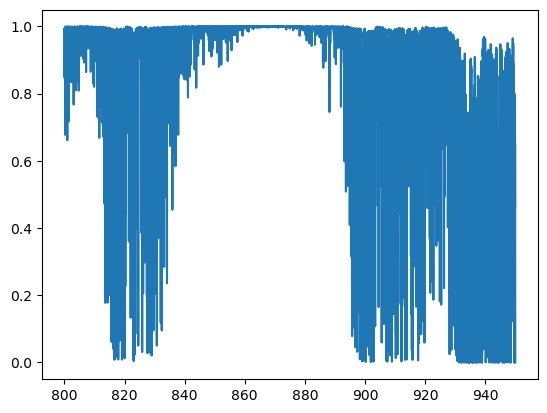

In [4]:
plt.plot(wl, trans_sample[20].T, label="model 0")

In [5]:
inspect_h5(CHUNK_H5)
inspect_h5(CHUNK_H50)


===== /home/mvasist/Documents/Tellurics/data/telluric_timeseries/chunks/chunk_000001.h5 =====
Top-level file attributes:
  conditions_h5 = /home/mvasist/Documents/Tellurics/site_parameter_evolution/telfit_condition_series.h5
  n_frames_per_series = 73
  samples_per_resolution_element = 3.0
  target_resolution = 100000
[dataset] failed_indices................ shape=(0,) dtype=int64
[dataset] labels........................ shape=(20, 20) dtype=float32
  attrs:
    columns = ['flat_index' 'series_index' 'frame_index' 'time_hours' 'pressure'
 'temperature' 'humidity' 'angle' 'airmass' 'co2' 'o3' 'n2o' 'co' 'ch4'
 'o2' 'no' 'so2' 'no2' 'nh3' 'hno3']
[dataset] transmission.................. shape=(20, 51557) dtype=float32
[dataset] wavelength.................... shape=(51557,) dtype=float32
  attrs:
    unit = nm

===== /home/mvasist/Documents/Tellurics/data/telluric_timeseries/chunks/chunk_000000.h5 =====
Top-level file attributes:
  conditions_h5 = /home/mvasist/Documents/Tellurics/site_p

In [6]:
# Closer look at chunk_000001.h5 contents (only read metadata + a small preview slice).
with h5py.File(CHUNK_H5, "r") as hf:
    n_models, n_wave = hf["transmission"].shape
    n_models_l, n_labels = hf["labels"].shape
    wlm = hf["wavelength"][:]
    cols = list(hf["labels"].attrs["columns"])

    trans_samplem = hf["transmission"][:5]
    labels_samplem = hf["labels"][:5]
    failed = hf["failed_indices"][:]

print("wavelength   :", wl.shape, wl.dtype, f"-> {wl.min():.3f} .. {wl.max():.3f} nm")
print("transmission : full shape", (n_models, n_wave), "float32 | preview", trans_samplem.shape, f"range [{trans_samplem.min():.4f}, {trans_samplem.max():.4f}]")
print("labels       : full shape", (n_models_l, n_labels), "float32")
print("  columns    :", cols)
print("failed_indices:", failed.shape, failed)

print("\nFirst 3 label rows:")
for i in range(min(3, labels_samplem.shape[0])):
    print(f"  model {i}: " + ", ".join(f"{c}={v:.4f}" for c, v in zip(cols, labels_samplem[i])))

wavelength   : (51556,) float64 -> 800.001 .. 950.000 nm
transmission : full shape (20, 51557) float32 | preview (5, 51557) range [0.0000, 1.0000]
labels       : full shape (20, 20) float32
  columns    : ['flat_index', 'series_index', 'frame_index', 'time_hours', 'pressure', 'temperature', 'humidity', 'angle', 'airmass', 'co2', 'o3', 'n2o', 'co', 'ch4', 'o2', 'no', 'so2', 'no2', 'nh3', 'hno3']
failed_indices: (0,) []

First 3 label rows:
  model 0: flat_index=20.0000, series_index=0.0000, frame_index=20.0000, time_hours=1.6667, pressure=743.5178, temperature=285.8480, humidity=50.8932, angle=48.7219, airmass=1.5158, co2=432.4499, o3=0.0362, n2o=0.3392, co=0.1400, ch4=1.9095, o2=210000.0000, no=0.0000, so2=0.0001, no2=0.0001, nh3=0.0001, hno3=0.0006
  model 1: flat_index=21.0000, series_index=0.0000, frame_index=21.0000, time_hours=1.7500, pressure=743.5470, temperature=285.8263, humidity=51.0472, angle=48.3689, airmass=1.5053, co2=432.4499, o3=0.0362, n2o=0.3392, co=0.1400, ch4=1.9095

In [7]:
# Closer look at chunk_000001.h5 contents (only read metadata + a small preview slice).
with h5py.File(CHUNK_H50, "r") as hf:
    n_models, n_wave = hf["transmission"].shape
    n_models_l, n_labels = hf["labels"].shape
    wlm0 = hf["wavelength"][:]
    cols = list(hf["labels"].attrs["columns"])

    trans_samplem0 = hf["transmission"][:5]
    labels_samplem0 = hf["labels"][:5]
    failed = hf["failed_indices"][:]

print("wavelength   :", wl.shape, wl.dtype, f"-> {wl.min():.3f} .. {wl.max():.3f} nm")
print("transmission : full shape", (n_models, n_wave), "float32 | preview", trans_samplem.shape, f"range [{trans_samplem.min():.4f}, {trans_samplem.max():.4f}]")
print("labels       : full shape", (n_models_l, n_labels), "float32")
print("  columns    :", cols)
print("failed_indices:", failed.shape, failed)

print("\nFirst 3 label rows:")
for i in range(min(3, labels_samplem.shape[0])):
    print(f"  model {i}: " + ", ".join(f"{c}={v:.4f}" for c, v in zip(cols, labels_samplem[i])))

wavelength   : (51556,) float64 -> 800.001 .. 950.000 nm
transmission : full shape (20, 51556) float32 | preview (5, 51557) range [0.0000, 1.0000]
labels       : full shape (20, 20) float32
  columns    : ['flat_index', 'series_index', 'frame_index', 'time_hours', 'pressure', 'temperature', 'humidity', 'angle', 'airmass', 'co2', 'o3', 'n2o', 'co', 'ch4', 'o2', 'no', 'so2', 'no2', 'nh3', 'hno3']
failed_indices: (0,) []

First 3 label rows:
  model 0: flat_index=20.0000, series_index=0.0000, frame_index=20.0000, time_hours=1.6667, pressure=743.5178, temperature=285.8480, humidity=50.8932, angle=48.7219, airmass=1.5158, co2=432.4499, o3=0.0362, n2o=0.3392, co=0.1400, ch4=1.9095, o2=210000.0000, no=0.0000, so2=0.0001, no2=0.0001, nh3=0.0001, hno3=0.0006
  model 1: flat_index=21.0000, series_index=0.0000, frame_index=21.0000, time_hours=1.7500, pressure=743.5470, temperature=285.8263, humidity=51.0472, angle=48.3689, airmass=1.5053, co2=432.4499, o3=0.0362, n2o=0.3392, co=0.1400, ch4=1.9095

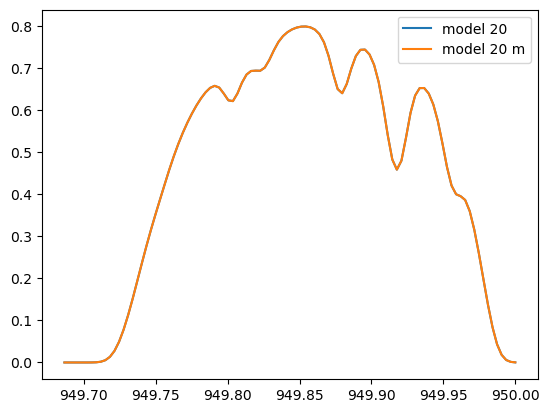

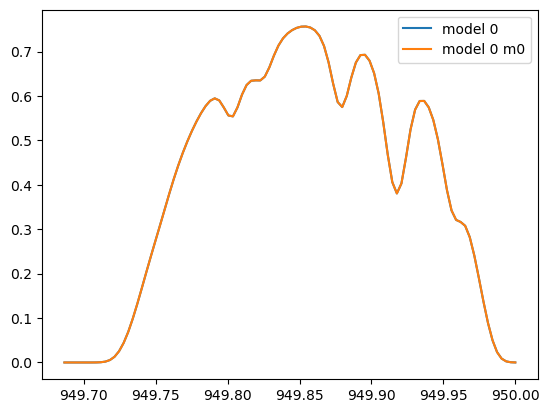

In [8]:
plt.plot(wl[-100:], trans_sample[20, -100:].T, label="model 20")
plt.plot(wlm[-100:], trans_samplem[0, -100:].T, label="model 20 m")
plt.legend()
plt.show()

plt.plot(wl[-100:], trans_sample[0, -100:].T, label="model 0")
plt.plot(wlm0[-100:], trans_samplem0[0, -100:].T, label="model 0 m0")

plt.legend()
plt.show()

In [9]:
np.shape(trans_sample), np.shape(trans_samplem), np.shape(trans_samplem0)

((50, 51556), (5, 51557), (5, 51556))

In [10]:
wl, wlm, wlm0

(array([800.0008011 , 800.00346776, 800.00613443, ..., 949.99366672,
        949.99683335, 950.        ]),
 array([800.     , 800.0027 , 800.0053 , ..., 949.99365, 949.9968 ,
        950.     ], dtype=float32),
 array([800.0008 , 800.0035 , 800.00616, ..., 949.99365, 949.9968 ,
        950.     ], dtype=float32))

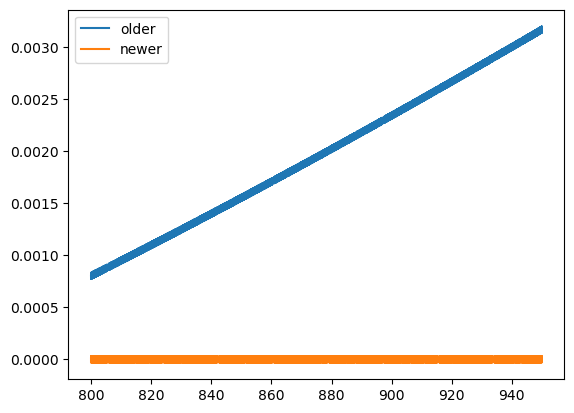

In [11]:
plt.plot(wl, wl - wlm[:-1], label = "older")
plt.plot(wl, wl - wlm0, label = "newer")
plt.legend()
plt.show()

In [12]:
n_intervals = int(
    np.ceil(
        np.log(0.95 / .800000801)
        * 100000
        * 3
    )
)
n_intervalsm = int(
    np.ceil(
        np.log(950 / 800)
        * 100000
        * 3
    )
)

n_intervals, n_intervalsm


(51555, 51556)

In [13]:
wwl = np.geomspace(
        .800000801,
        0.95,
        n_intervals + 1,
        )
wwlm = np.geomspace(
        800,
        950,
        n_intervalsm + 1,
        )

In [14]:
wwl*1000, np.asarray(wwlm, float)

(array([800.000801  , 800.00346766, 800.00613433, ..., 949.99366672,
        949.99683335, 950.        ]),
 array([800.        , 800.00266662, 800.00533326, ..., 949.9936668 ,
        949.9968334 , 950.        ]))